# Emerging Technologies
<hr>

**Name**: Macdarach Carty Joyce <br>
**ID**: G00394925

## Introduction
<hr>

This notebook outlines a series of problems relating to the Deutsch-Jozsa algorithm, and a practical demonstration of Quantum Information: a way of leveraging **superposition** to solve a problem faster than Classical Information. There are 5 problems in total, where each encompass a programmatic solution to the problem with supporting markdown providing background and context to the objectives.

The problems are as follows:
- [Problem 1: Generating Random Boolean Functions](#problem-1-generating-random-boolean-functions)
- [Problem 2: Classical Testing for Function Type](#problem-2-classical-testing-for-function-type)
- [Problem 3: Quantum Oracles](#problem-3-quantum-oracles)
- [Problem 4: Deutsch's Algorithm with Qiskit](#problem-4-deutschs-algorithm-with-qiskit)
- [Problem 5: Scaling to the Deutch-Jozsa Algorithm](#problem-5-scaling-to-the-deutsch-jozsa-algorithm)

The problems follow a chronology, establishing initial concepts before fully demonstrating the efficiency of Quantum Information. 

### Setup & Imports

In [1]:
import numpy as np
import random
import itertools
import qiskit
import qiskit_aer as aer
import matplotlib.pyplot as plt
import pylatexenc

## Problem 1: Generating Random Boolean Functions
<hr>

The purpose of the [Deutsch-Jozsa](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm) algorithm is to determine a global property of a function after a single query. The goal is to assert whether the function is *constant* (always returns 0 or 1 for all input combinations) or *balanced* (returns 1 for half of the possible input combinations). 

**This problem** relates to the implementation of a function that returns a boolean output based on a fixed number of boolean inputs. The function of course may either be *constant* or *balanced*. The technical implementation involves **generating and returning a function from *within* another function**, the former of which then **returns a boolean output**. The goal is to implement this so that the nature of the function (be it constant or balanced) remains unknown to the observer.

In this case, for $x=\{0,1\}$, a randomly chosen function will either be: 
- **Constant**: Always return 0 ($f_0$) or always return 1 ($f_3$) regardless of input combination.
- **Balanced**: Return 0 for half of the input combinations and 1 for the other half ($f_1, f_2$).   

And the four possible boolean functions of [Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) are as follows: 

| $x$ | $f_0(x)$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ |
|-----|---------|---------|---------|---------|
|  0  |    0    |    0    |    1    |    1    |
|  1  |    0    |    1    |    0    |    1    |

If a function takes $n$ input bits, there would be $2^n$ possible input combinations. So, if $n = 4$, there would be $2^4 = 16$ possible input combinations. All 4-bit binary strings are subsequently generated: $[0, 0, 0, 0], [0, 0, 0, 1], ... , [1, 1, 1, 1]$, and once all possible combinations are acquired, only the constant (all 0's or 1's) or balanced (exactly half 1's) strings are returned.

### Acquiring all possible binary strings

In [2]:
def constant_and_balanced_strings(n):
    """
    Generates all constant and balanced binary strings of length n.
    
    Parameters:
        n (int): Length of the binary strings.
    Returns:
        np.ndarray: Array of constant and balanced binary strings.
    """
    # Generate all possible binary strings of length n
    all_binary_strings = ((np.arange(2**n)[:, None] & (1 << np.arange(n-1, -1, -1))) > 0).astype(int)

    # Acquire the sum of ones in each binary string
    ones = all_binary_strings.sum(axis=1)

    # Length of a binary string
    str_len = all_binary_strings.shape[1]

    # Return only the constant (all 0s or all 1s) or balanced (equal number of 0s and 1s) strings
    return all_binary_strings[(ones == 0) | (ones == str_len) | (ones == str_len // 2)]

Upon acquiring the strings, a random choice is made to either use a constant or balanced string before proceeding to choose a random string of either category to use as the truth table for the function. An inner variadic function is generated which maps the boolean inputs to an index of the truth table. This index is calculated using standard [binary-to-decimal conversion](https://www.geeksforgeeks.org/utilities/binary-to-decimal/). 

Given $n$ binary inputs, the binary-to-decimal conversion formula would be as follows: 
$$
b_0 \times 2^0 + b_1 \times 2^1 + ... + b_{n-1} \times 2^{n-1}
$$

So, if $n$ were to equal $4$, the length of the generated strings would be 16. One of these strings is randomly selected as the truth table for the function, which could look like: 
$$
[1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0]
$$

The truth table defines a list of possible outputs for each of the $16$ possible input iterations. The output can be accessed via the value's index, $[0...15]$ in this case, by calculating it using the binary to decimal conversion formula. 

If the submitted boolean inputs were to be $(0, 1, 0, 1)$, by reversing the bit order to start with the least significant bit, the index can be calculated as follows:

$$
1 \times 2^0 + 0 \times 2^1 + 1 \times 2^2 + 0 \times 2^3 = 1 + 0 + 4 + 0 = 5
$$. 

Element $[5]$ is then acquired from the above truth table, which is $0$. Therefore, the specific input combination of $(0, 1, 0, 1)$ returns an output of 0.

### Generate and return the function 

In [3]:
def random_constant_balanced(n, function_type=None):
    """
    Creates and returns a function that randomly selects a binary string.

    Parameters:
        n (int): Number of input bits for the function.
        function_type (str, optional): Specify to explicitly select a constant or balanced function. If None, type is randomly chosen.
    Returns:
        function: A function that maps n inputs to a randomly selected constant or balanced binary string.
    """
    
    # Acquire all constant and balanced binary strings of length 2^n
    strings = constant_and_balanced_strings(2 ** n)

    # Get the strings that are either constant or balanced.
    # Anything else is ignored and discarded
    #
    # 
    # String is constant if sum of bits = 0 or sum = length of string -- all bits are 0 or all 1
    constant_strings = [s for s in strings if s.sum() == 0 or s.sum() == len(s)]
    # String is balanced if the sum of the bits is equal to half of the length of the string.
    # -- For a binary string length of 4; if the sum == 2, then there are two 1's and two 0's. 
    balanced_strings = [s for s in strings if s.sum() == len(s) // 2]

    # Decide whether to select a constant or balanced string.
    string_type = function_type if function_type is not None else random.choice(['constant', 'balanced'])

    # Randomly select one of these strings
    if string_type == 'constant':
        random_string = random.choice(constant_strings)
    else:
        random_string = random.choice(balanced_strings)

    
    def f(*args):
        """
        Maps n inputs to the corresponding bit in the randomly selected binary string.

        Parameters:
            *args: n binary inputs (0 or 1).
        Returns:
            int: The bit in the random string corresponding to the binary index formed by the inputs.
        """

        index = 0

        # Get index from binary inputs
        for i, bit in enumerate(reversed(args)):
            # Calculate the index in decimal (bit*2^0 + bit*2^1 + ... + bit*2^(n-1))
            index += (bit * (2 ** i))
            
        return int(random_string[index])
    
    # Store no. of inputs and type as attributes for later use
    f.n = n
    f.type = string_type
    
    return f

### Test the function

A function is then generated and acquired, being one of the four possible boolean functions outlined above. It is intially unknown what type of function was returned, but this will be tested in the next problem.

In [4]:
n = 4  # 4 bits will be used

# Acquire the function 
f = random_constant_balanced(n)

In [5]:
# Test the function with binary inputs
# The type of function is not immediately clear.
print(f(1, 0, 1, 0))

1


## Problem 2: Classical Testing for Function Type
<hr>

This section involves determining whether the function previously generated in [Problem 1](#problem-1-generating-random-boolean-functions) is constant or balanced. This is a [Classical](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/classical-information) approach; that is, the state of the function is clearly observed and known with certainty. If this determination were to be labelled as X, and there is a 50% chance of the function being either constant or balanced, we can represent the probabilities as:

$$Pr(X = constant) = \frac{1}{2} \quad \text{and} \quad Pr(X = balanced) = \frac{1}{2}$$

which can also be represented as a **column vector**: 

$$\begin{pmatrix} \frac{1}{2} \\ \\ \frac{1}{2} \end{pmatrix}$$

where the probability of the function being *constant* is placed at the top position, and the probability of the function being *balanced* is placed at the bottom, as well as the sum of these entries being always equal to 1.

The four possible functions of [Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) can be represented as a 2x2 matrix, showing the output for each input:

$$
f_0(x) = \begin{pmatrix} 1 \quad 1 \\ 0 \quad 0 \end{pmatrix} \quad
f_1(x) = \begin{pmatrix} 1 \quad 0 \\ 0 \quad 1 \end{pmatrix} \quad
f_2(x) = \begin{pmatrix} 0 \quad 1 \\ 1 \quad 0 \end{pmatrix} \quad
f_3(x) = \begin{pmatrix} 0 \quad 0 \\ 1 \quad 1 \end{pmatrix} \quad
$$

When the the outcome of *determine_constant_balanced(f)* is observed, the classical state of the given function is known with certainty. This can be represented as a standard basis vector using the **dirac** notation, and is represented as:

$$
|constant\rangle = \begin{pmatrix} 
    1 \\ 0 
\end{pmatrix}

\quad \text{and} \quad

|balanced\rangle = \begin{pmatrix}
    0 \\ 1
\end{pmatrix}
$$

This type of notation will be further used in Problems [3](#problem-3-quantum-oracles) and [4](#problem-4-deutschs-algorithm-with-qiskit).

 In this approach, the output is determined by iterating through all possible input combinations against the truth table and analysing the result of $f$. The logic is as follows:

1. Get the output for the first input combination.
2. Iterate through the remaining operations.
3. If any output differs from the previous output, the function must be **balanced**.
4. If over half of the outputs are the same or the loop completes, the function must be **constant**.

This can be determined after a minimum of 2 iterations (where the function is balanced), or after a maximum of $2^{n-1} + 1$ iterations, where $n$ is equivalent to the number of input bits. Given that $n = 4$, the worst case scenario would require $2^{4-1} + 1 = 9$ iterations to determine the function type.

In [6]:
def determine_constant_balanced(f, verbose=True):
    """
    Determines whether the given function is constant (returns 0 or 1 for all inputs) or 
    balanced (returns 0 for half of the inputs, 1 for the other half).

    Parameters: 
        f (function): The generated function being tested.

    Returns:
        A string saying whether the function is constant or balanced.
    """
    
    n = f.n  # Get number of inputs from the function attribute
    previous_output = None

    # Generate all possible input combinations dynamically
    all_inputs = itertools.product([0, 1], repeat=n)

    # Run f for all possible input combinations
    for i, inputs in enumerate(all_inputs):        
        out = f(*inputs)
        print(f"{i}. {inputs}  =>  {out}") if verbose else None
        
        if previous_output is not None:
            # Output is different across different input combinations -- must be balanced.
            if out != previous_output:
                return "Balanced"
        
        # If over half of the input combinations are the same -- must be constant.
        if i == 2**(n-1):
            return "Constant"
        
        # Store current output to compare with in next iteration.
        previous_output = out
    
    return "Constant"  # If all outputs are the same

### Execute the Function

The input size ($n$) is set to $4$ and both a balanced function and a constant function that takes $4$ boolean inputs will be created.

In [7]:
# Number of input bits
n = 4

In [8]:
# Create a classical and a balanced function 
classical_balanced = random_constant_balanced(n, function_type='balanced')
classical_constant = random_constant_balanced(n, function_type='constant')

The constant function's type will be determined classically. Normally, the function type would NOT be intially known, but the type is pre-determined in order to demonstrate this process.

The following test shows that the function type is determined as 'constant' after 9 iterations. This is the worst case scenario in terms of processing time, but is necessary to determine that it is indeed constant as, while unlikely, it can still potentially be a 'balanced' function after the first 8 iterations.

In [9]:
# Test constant function
determine_constant_balanced(classical_constant)

0. (0, 0, 0, 0)  =>  0
1. (0, 0, 0, 1)  =>  0
2. (0, 0, 1, 0)  =>  0
3. (0, 0, 1, 1)  =>  0
4. (0, 1, 0, 0)  =>  0
5. (0, 1, 0, 1)  =>  0
6. (0, 1, 1, 0)  =>  0
7. (0, 1, 1, 1)  =>  0
8. (1, 0, 0, 0)  =>  0


'Constant'

The balanced function is then determined, and as shown, is done so by ceasing after any change in the output.

In [10]:
# Test balanced function
determine_constant_balanced(classical_balanced)

0. (0, 0, 0, 0)  =>  1
1. (0, 0, 0, 1)  =>  1
2. (0, 0, 1, 0)  =>  1
3. (0, 0, 1, 1)  =>  0


'Balanced'

### True Random Test

The next function will be created with the type being truly unknown to the observer, before then being determined by the classical method.

In [11]:
# Create and test a random function
random_function = random_constant_balanced(n)

determine_constant_balanced(random_function)

0. (0, 0, 0, 0)  =>  0
1. (0, 0, 0, 1)  =>  0
2. (0, 0, 1, 0)  =>  1


'Balanced'

The classical algorithm correctly identifies the type of function; however, as demonstrated, the number of queries required to determine the function time *exponentially* increases relative to $n$. While the state of the query can be easily known with certainty, the performance of this classical method pales in comparison to quantum methods, which will be demonstrated in the next problems.

## Problem 3: Quantum Oracles
<hr>


In [Quantum Information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/quantum-information), unlike classical information, the state of a given input is measured more arbitrarily than that of classical states. A quantum state differs to a classical probabilisitic state, where entries of a quantum state vector are *complex numbers*, and that the sum of the *absolute values squared* of the entries is equal to $1$. In a classical state set of $\{0, 1\}$, the term *qubit* is used to refer to a unit of quantum information. 

The processing of quantum information differs to classical information; a process that evaluates a function $f$ using an input of 0 or 1 to determine whether it is **constant** or **balanced** would have to be run at least twice under classical methods (as demonstrated in [Problem 2](#problem-2-classical-testing-for-function-type)), whereas the use of quantum information and operations allows for the determination of $f$ in [one evaluation](https://plato.stanford.edu/archives/fall2008/entries/qt-entangle/#5). 

With the operation being unknown to the observer, the only properties that are known are the inputs supplied and the given outputs. With regards to the previous problems; in the case of a single input, there are four possible Boolean functions. This section sees the creation of a quantum oracle using *Qiskit* for each of the possible single-Boolean-input functions.

[Quantum Oracles](https://quantumcomputing.stackexchange.com/questions/4625/what-exactly-is-an-oracle/4626#4626) act as the 'black-box' operations that evaluate $f$. In order to do this, it must be ensured that $f$ is invertible, as the input would not be known for all functions (constant 0 always produces an output of 0, but it would not be known whether the input was 0 or 1). 

In Deutsch's Algorithm, two qubits ($x, y$) are used: $x$ representing the **input qubit** and $y$ being the **ancilla qubit**, the latter of which ensure invertibility and whose measurement produces a meaningful output. The outputs produced are ($x, y \oplus f(x)$), where $\oplus$ is the XOR value. So, the transformation is implemented as: 

$\ket{x}\ket{y} \rightarrow \ket{x} \ket{y} \oplus \ket{f(x)}$ 

and $f$ could be one of the four functions in Deutsch's Problem: 


| $x$ | $f_0(x)$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ |
|:---:|:-------:|:-------:|:-------:|:-------:|
|  0  |    0    |    0    |    1    |    1    |
|  1  |    0    |    1    |    0    |    1    |

### Creating the Quantum Oracles
State vectors can be used to map the outputs to a 4x4 unitary matrix which is then used as the oracle. The initial state vectors are acquired by calculating the tensor product of the column vectors of two inputs. For example, given the function being used is the *identity* function and the inputs $x, y$ were $(1, 0)$ = $\ket{10}$ respectively, then the output results $f_1(1) = 1$ and $y \oplus f(x) = 1$ can be represented as $\ket{11}$.

The output state vector that follows can be calculated as:

$$
\ket{11} = \begin{pmatrix} 0 \\ 1 \end{pmatrix} \otimes \begin{pmatrix} 0 \\ 1 \end{pmatrix} = 
\begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix}
$$

The input state vector $\ket{10}$ can be mapped to the output state vector $\ket{11}$

$$\ket{10} = \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix} \rightarrow \ket{11} = \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix}$$


The state vectors follow the rule where the sum of all absolute values of the entries squared is equal to 1.

### Quantum Oracle for $f_0(x)$ - **Constant $0$**
Constant 0 function returns an output of 0 regardless of the input state:

$f(0) = 0 \quad f(1) = 0$

We also calculate $y \oplus f(x)$ to get the XOR of the two qubits and the output.

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 0 | 0 |
|  0  |  1  |  $\rightarrow$ | 0 | 1 |
|  1  |  0  |  $\rightarrow$ | 0 | 0 |
|  1  |  1  |  $\rightarrow$ | 0 | 1 |

Represented using the dirac notation: 


$$\ket{00} \rightarrow \ket{00}$$
$$\ket{01} \rightarrow \ket{01}$$
$$\ket{10} \rightarrow \ket{10}$$
$$\ket{11} \rightarrow \ket{11}$$

For this particular function, the output remains unchanged from the input. We can these results as column state vectors: 

$$U\begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix}$$

The row vector is acquired from each of these mappings so that 
$$r_0 \begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \ket{00} \rightarrow r_0 = (1 \quad 0 \quad 0 \quad 0) $$

This is repeated for the rest of the outputs, after which each row vector can be placed into a 4x4 unitary matrix.

$$
U_{f_0} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
$$

Which is also the same as: 
$$
I \otimes I = 
\begin{pmatrix}
1 & 0 \\ 0 & 1
\end{pmatrix}
\otimes
\begin{pmatrix}
1 & 0 \\ 0 & 1
\end{pmatrix} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
$$

Hence, the oracle for $f_0$ is created.

### Code Implementation

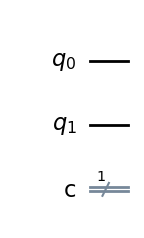

In [12]:
# Create oracle for constant 0 function
# Two qubits as inputs with one classical bit
oracle_0 = qiskit.QuantumCircuit(2, 1)

# Constant 0 function does not modify input qubits, so the oracle does not apply any gates in the circuit
# and leaves the qubits as they are.
oracle_0.draw('mpl')

### Quantum Oracle for $f_1(x)$ - **Identity Function**

The Identify function is one of the **balanced** functions, where it may return either 0 or 1. The Identity function returns whatever value the input was:

$f_1(0) = 0 \quad f_1(1) = 1$

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 0 | 0 |
|  0  |  1  |  $\rightarrow$ | 0 | 1 |
|  1  |  0  |  $\rightarrow$ | 1 | 1 |
|  1  |  1  |  $\rightarrow$ | 1 | 0 |

For the quantum circuit, since all qubits start at 0, the bit must be *flipped* if the input is 1, otherwise does nothing if the input is 0.

Once again, using the dirac notation to represent the inputs and outputs:


$$\ket{00} \rightarrow \ket{00}$$
$$\ket{01} \rightarrow \ket{01}$$
$$\ket{10} \rightarrow \ket{11}$$
$$\ket{11} \rightarrow \ket{10}$$


and mapping to their state row vectors: 

$$U\begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{11} \\ \ket{10} \end{pmatrix}$$

<br>

$$r_0 = \ket{00} \rightarrow r_0 = (1 \quad 0 \quad 0 \quad 0) $$
$$r_1 = \ket{01} \rightarrow r_1 = (0 \quad 1 \quad 0 \quad 0) $$
$$r_2 = \ket{11} \rightarrow r_2 = (0 \quad 0 \quad 0 \quad 1) $$
$$r_3 = \ket{10} \rightarrow r_3 = (0 \quad 0 \quad 1 \quad 0) $$


The result being the **Controlled-Not** gate:

$$
U_{f_1} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix} = CX
$$


### Code Implementation

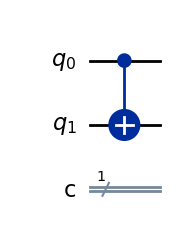

In [13]:
oracle_1 = qiskit.QuantumCircuit(2, 1)

# Apply the Controlled-NOT (CNOT) gate to flip the qubit if the input is 1.
oracle_1.cx(0, 1)

oracle_1.draw('mpl')

### Quantum Oracle for $f_2(x)$ - **NOT function**
The NOT function is another balanced function, and returns the opposite value of the given input:

$f_2(0) = 1 \quad f_2(1) = 0$

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 1 | 1 |
|  0  |  1  |  $\rightarrow$ | 1 | 0 |
|  1  |  0  |  $\rightarrow$ | 0 | 0 |
|  1  |  1  |  $\rightarrow$ | 0 | 1 |

$$\ket{00} \rightarrow \ket{01}$$
$$\ket{01} \rightarrow \ket{00}$$
$$\ket{10} \rightarrow \ket{10}$$
$$\ket{11} \rightarrow \ket{11}$$

When mapped:

$$U\begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \begin{pmatrix} \ket{01} \\ \ket{00} \\ \ket{10} \\ \ket{11} \end{pmatrix}$$

<br>

$$r_0 = \ket{01} \rightarrow r_0 = (0 \quad 1 \quad 0 \quad 0)$$
$$r_1 = \ket{00} \rightarrow r_1 = (1 \quad 0 \quad 0 \quad 0)$$
$$r_2 = \ket{10} \rightarrow r_2 = (0 \quad 0 \quad 1 \quad 0)$$
$$r_3 = \ket{11} \rightarrow r_3 = (0 \quad 0 \quad 0 \quad 1)$$

<br>

$$
U_{f_2} = \begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix} = I \otimes X(CX)
$$

### Code Implementation

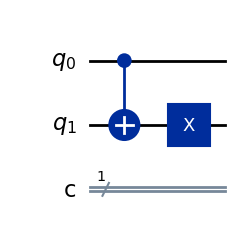

In [14]:
oracle_2 = qiskit.QuantumCircuit(2, 1)

# Apply the CNOT gate to flip the second qubit if and ONLY if input is |1>.
oracle_2.cx(0, 1)

# Apply the X gate to flip the target qubit.
oracle_2.x(1)

oracle_2.draw('mpl')

### Quantum Oracle for $f_3(x)$ - **Constant $1$**

The constant 1 function returns an output of 1 regardless of the state the input is in:

$f_3(0) = 1 \quad f_3(1) = 1$

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 1 | 1 |
|  0  |  1  |  $\rightarrow$ | 1 | 0 |
|  1  |  0  |  $\rightarrow$ | 1 | 1 |
|  1  |  1  |  $\rightarrow$ | 1 | 0 |


$$\ket{00} \rightarrow \ket{01}$$
$$\ket{01} \rightarrow \ket{00}$$
$$\ket{10} \rightarrow \ket{11}$$
$$\ket{11} \rightarrow \ket{10}$$

When mapped:

$$U\begin{pmatrix} \ket{00} \\ \ket{01} \\ \ket{10} \\ \ket{11} \end{pmatrix} = \begin{pmatrix} \ket{01} \\ \ket{00} \\ \ket{11} \\ \ket{10} \end{pmatrix}$$

<br>


$$r_0 = \ket{01} \rightarrow r_0 = (0 \quad 1 \quad 0 \quad 0)$$
$$r_1 = \ket{00} \rightarrow r_1 = (1 \quad 0 \quad 0 \quad 0)$$
$$r_2 = \ket{11} \rightarrow r_2 = (0 \quad 0 \quad 0 \quad 1)$$
$$r_3 = \ket{10} \rightarrow r_3 = (0 \quad 0 \quad 1 \quad 0)$$

<br>

$$
U_{f_3} = \begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix} = I \otimes X
$$

### Code Implementation

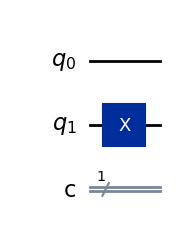

In [15]:
oracle_3 = qiskit.QuantumCircuit(2, 1)

# Since output would always be 1, apply the X gate to flip the qubit.
oracle_3.x(1)
oracle_3.draw('mpl')

## Problem 4: Deutsch's Algorithm with Qiskit
<hr>

This section sees the creation of a *quantum circuit* using each of the oracles created in [Problem 3](#problem-3-quantum-oracles) to solve [Deutsch's problem](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm). The circuit would allow the observer to determine whether the function being tested is constant or balanced after one query. 

Deutsch's Algorithm involves a *single input qubit*, as well as an [ancilla](https://en.wikipedia.org/wiki/Ancilla_bit) qubit, the latter being an auxillary qubit served to measure the state of the input and ensures reversibility.

In a typical quantum circuit, all qubits are intially set to the state $\ket{0}$, which can then be transformed by a series of gates/operations to produce an output of either $\ket{0}$ if the function is constant, or $\ket{1}$ if the function is balanced. One of these being the [Hadamard operation](https://pennylane.ai/qml/glossary/what-is-a-hadamard-gate), which transforms the state of a qubit into a state of a superposition between $\ket{0}$ and $\ket{1}$. Applying the Hadamard operation again to the same qubit reverses the transformation, collapsing the state of superposition.

The state of superposition can be represented using the diract notation: if the input qubit was $\ket{0}$, then the state of superposition can be represented as $(\ket{0} + \ket{1})/\sqrt{2}$, or if the input qubit was $\ket{1}$, this would be represented as $(\ket{0} - \ket{1})/\sqrt{2}$. These can also be written as $\ket{+}$ and $\ket{-}$ respectively.


Representing the Hadamard gate as a matrix is done as:
$$
H = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix}
$$



This gate is applied to both qubits at the start of the circuit, before then being transformed by the oracle for the respective function. This is always the first step of the quantum circuit regardless of the function being used.

### Initial state vectors

The circuit can be computed and *verified* through a series of matrix multiplications starting with the **intital state vectors** of each possible input. The intial state vectors can be computed by acquiring the tensor product of the column vectors of a multi-qubit state. 

$$ 
\ket{00} = \begin{pmatrix} 1 \\ 0 \end{pmatrix} \otimes \begin{pmatrix} 1 \\ 0 \end{pmatrix} 
= \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix} \quad

\ket{01} = \begin{pmatrix} 1 \\ 0 \end{pmatrix} \otimes \begin{pmatrix} 0 \\ 1 \end{pmatrix} 
= \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix} \quad
$$
$$
\ket{10} = \begin{pmatrix} 0 \\ 1 \end{pmatrix} \otimes \begin{pmatrix} 1 \\ 0 \end{pmatrix} 
= \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix} \quad

\ket{11} = \begin{pmatrix} 0 \\ 1 \end{pmatrix} \otimes \begin{pmatrix} 0 \\ 1 \end{pmatrix} 
= \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix} \quad
$$


### Beginning the Circuit

At the start of the circuit, both qubits are initialised as $\ket{0}$. The second qubit can be flipped to $\ket{1}$ by applying the NOT gate ($X$) to it before applying any other operation.

$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

The first qubit is left alone, which is equivalent to applying the Identity gate ($I$).

$$I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$$

Hence, the first computational step of the quantum circuit is multiplying the initial state vector with the *tensor product of $I$ and $X$*. If the input were to be $\ket{00}$, the matrix multiplication steps thus far look like:

$$ I \otimes X = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} \otimes \begin{pmatrix} 0 & 1 \\ 1 & 0\end{pmatrix}
= \begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}

\cdot \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix} = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix}
$$

A Hadamard operation is then applied to both qubits so as to transform them into a state of superposition. Since there is a Hadamard operation for each qubit, the tensor product of two Hadamard gates is calculated. 

$$
H \otimes H = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix} \otimes \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix} 
= \frac{1}{2} \begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{pmatrix}

\cdot \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix} = \frac{1}{2}\begin{pmatrix}1 \\ -1 \\ 1 \\ -1 \end{pmatrix}
$$


### Code Example - Start

This code shows the quantum circuit that had been computed thus far. The two qubits are initialised to $\ket{0}$, hence the X gate flips $q_1$ to $\ket{1}$. There is no identity gate shown for $q_0$, as it does not need to be represented since it does not affect the state of the qubit. The transformation $I \otimes X$ is still performed regardless.

The two Hadamard gates are also shown, applied to both qubits.

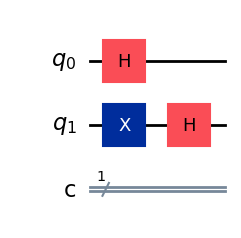

In [16]:
# The beginning portion of the overall circuit
deutsch_s = qiskit.QuantumCircuit(2, 1)

# Apply the NOT gate to q1 to flip state from |0> to |1>.
deutsch_s.x(1)

# Apply Hadamard gates to both qubits
deutsch_s.h((0, 1))

deutsch_s.draw(output='mpl')

### Applying the Quantum Oracle to the Circuit

The next verification step is applying one of the oracles generated in [Problem 3](#problem-3-quantum-oracles) to the circuit. The identity function will be used in this verification example, the oracle of which implementing the CNOT gate. 

$$
CX = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}
$$

Then, performing matrix multiplication with the current state vector:
$$
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}

\cdot \frac{1}{2} \begin{pmatrix} 1 \\ -1 \\ 1 \\ -1 \end{pmatrix} = \frac{1}{2} \begin{pmatrix} 1 \\ -1 \\ -1 \\ 1 \end{pmatrix}
$$

Following this controlled operation, the circuit experiences a phenomenon in which the state of the *ancilla* qubit influences the state of the *input* qubit, despite the latter not being directly modified. This is known as [Phase kickback](https://en.wikipedia.org/wiki/Phase_kickback), and it occurs while these qubits are in states of superposition. This is a unique quality of quantum computing, and it allows to determine the final output.



### Completing the Circuit

Upon completion of the oracle transformation, another Hadamard gate is applied to the top qubit, whereas the bottom qubit is left unchanged. This is equivalent to $H \otimes I$, and is calculated as follows:

$$
H \otimes I = \frac{1}{\sqrt{2}} \begin{pmatrix}1 & 1 \\ 1 & -1 \end{pmatrix} \otimes \begin{pmatrix}1 & 0 \\ 0 & 1 \end{pmatrix}
= \frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 \\
1 & 0 & -1 & 0 \\
0 & 1 & 0 & -1
\end{pmatrix}
$$

Hence the final transformation of the current state can be represented as follows:

$$
\frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 \\
1 & 0 & -1 & 0 \\
0 & 1 & 0 & -1
\end{pmatrix}

\cdot \frac{1}{2}\begin{pmatrix}1 \\ -1 \\ -1 \\ 1 \end{pmatrix} = \frac{1}{2\sqrt{2}} \begin{pmatrix} 0 \\ 0 \\ 2 \\ -2 \end{pmatrix} 
= \frac{1}{\sqrt{2}} \begin{pmatrix} 0 \\ 0 \\ 1 \\ -1 \end{pmatrix}
$$ 

The final state vector has a value greater than zero on the positions $\ket{10}$ and $\ket{11}$. So, the output of the first qubit after completing the circuit is $\ket{1}$, meaning after just one query, it is known that this is a *balanced* function. Should the output have been $\ket{0}$, it would have been a *constant* function. 

If we used the *constant 1* function as an example, the sequence would be as follows

$$
\frac{1}{2\sqrt{2}} \begin{pmatrix}
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 \\
1 & 0 & -1 & 0 \\
0 & 1 & 0 & -1
\end{pmatrix}

\begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}

\begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{pmatrix}

\begin{pmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}

\begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix} = 
\frac{1}{2\sqrt{2}} \begin{pmatrix} -2 \\ 2 \\ 0 \\ 0 \end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix} -1 \\ 1 \\ 0 \\ 0 \end{pmatrix} 
$$

The second matrix from the left is the oracle of the constant 1 function, being $I \otimes X$. Following the transformation, the positions with a value greater than 0 are $\ket{00}$ and $\ket{01}$, which verifies that this is a *constant* function.

### Code Example - End

The final Hadamard gate is applied to the first qubit, which then has its state measured and returns an output.

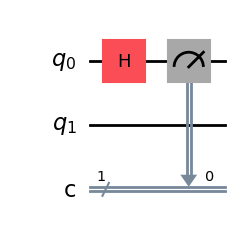

In [17]:
# Create end part of circuit
deutsch_e = qiskit.QuantumCircuit(2, 1)

# Apply final Hadamard gate to first qubit
deutsch_e.h(0)

deutsch_e.measure(0, 0)

deutsch_e.draw(output='mpl')

### Full Example Circuit Composition

The below code then fully composes all parts of an example Deutsch's circuit, using the identity oracle in this case. Usually, it would not be known whichever oracle was used, but one is explicity chosen and used here for illustrative purposes.

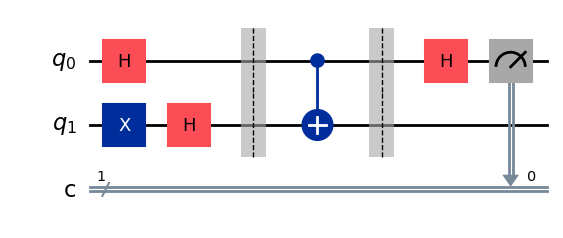

In [18]:
# Create a full circuit composed of start, end and oracle
full_circuit = qiskit.QuantumCircuit(2, 1)

# Add beginning of circuit
full_circuit.compose(deutsch_s, inplace=True)
full_circuit.barrier()

# Use identity function oracle as example
full_circuit.compose(oracle_1, inplace=True)
full_circuit.barrier()

# Add end of circuit
full_circuit.compose(deutsch_e, inplace=True)

full_circuit.draw(output='mpl')

### Running Deutsch's Algorithm with Simulator

This following code composes a full Deutsch algorithm circuit, which is compiled and run by a [quantum computing simulator](https://qiskit.github.io/qiskit-aer/). Returns either $0$ or $1$ if the function is constant or balanced respectively.

In [19]:
def run_circuit(oracle):
	"""
	Runs the Deutsch algorithm circuit
	
	Params: 
		oracle (QuantumCircuit): The oracle to be used in the circuit.
		
	Returns:
		'0' if the function is constant, '1' if the function is balanced.	
	"""

	# Start of circuit
	start = qiskit.QuantumCircuit(2, 1)
	# Set second qubit to |1>
	start.x(1)
	# Apply Hadamard gates to both qubits
	start.h((0, 1))

	# End of circuit
	end = qiskit.QuantumCircuit(2, 1)
	# Apply final Hadamard gate to first qubit
	end.h(0)
	# Measure the first qubit
	end.measure(0, 0)

	# Compose the full circuit with oracle
	qc = qiskit.QuantumCircuit(2, 1)
	qc.compose(start, inplace=True)
	qc.compose(oracle, inplace=True)
	qc.compose(end, inplace=True)

	# Initialise AER simulator
	simulator = aer.AerSimulator()
	# Compile the circuit for simulator
	compiled_circuit = qiskit.transpile(qc, simulator)
	# Run circuit
	result = simulator.run(compiled_circuit, shots=1024).result()

	return result.get_counts()

The circuit is then run for each oracle; their outputs shown below. Each output can be seen to correctly correlate with the type of function tested (the constant functions $f_0$ and $f_3$ output 0, and balanced functions $f_1$ and $f_2$ output 1).

In [20]:
oracles = [oracle_0, oracle_1, oracle_2, oracle_3]

# Test oracles
# '[{'0': 1024}, {'1': 1024}, {'1': 1024}, {'0': 1024}]'
# => 'Constant', 'Balanced', 'Balanced', 'Constant'
[run_circuit(oracle) for oracle in oracles]

[{'0': 1024}, {'1': 1024}, {'1': 1024}, {'0': 1024}]

In [21]:
# Randomly choose an oracle
run_circuit(random.choice(oracles))

{'1': 1024}

## Problem 5: Scaling to the Deutsch-Jozsa Algorithm
<hr>

The [Deutsch-Jozsa Algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) extends **Deutsch's Algorithm** where it analyses a function that takes **multiple** inputs instead of one after just **one query**. 

It is one of the [first examples](https://en.wikipedia.org/wiki/Deutsch%E2%80%93Jozsa_algorithm) to highlight how exponentially faster quantum algorithms can be over classical algorithms. In [Problem 2](#problem-2-classical-testing-for-function-type), it was demonstrated that the function type could be determined by classical methods after $2^{n-1}$ queries in a worst case scenario. This section will see this done in just one query, regardless of the size of $n$.

The algorithm will see the solution to the problem upon measuring all $n$ input qubits, if all results are $0$, then the function is *constant*. If any result is $1$, then the function is *balanced*.

In this problem, $n = 4$ input bits will be used, which when scaled to the Deutsch-Jozsa algorithm will require $5$ total qubits, one of which being the *ancilla* qubit to measure the states of the input qubits. $4$ functions will be generated, $2$ of which being constant and the other $2$ being balanced, before then running the circuit on them to correctly identify their type. Creation of the classical functions is using `random_constant_balanced` defined in [Problem 1](#problem-1-generating-random-boolean-functions), which will be used in this problem to create another Quantum Circuit using Qiskit.

In [22]:
n = 4  # 4 input bits will be used

### Generating the Classical Functions

The function <code>random_constant_balanced</code> from Problem 1 will be called to generate $4$ functions using $n$ input bits. $2$ constant functions and $2$ balanced will be created.

In [23]:
functions = []

# Generate 2 constant and 2 balanced functions
for i in range(2):
	functions.append(random_constant_balanced(4, function_type='constant'))
for i in range(2):
	functions.append(random_constant_balanced(4, function_type='balanced'))

# Shuffle to randomise their order
random.shuffle(functions)

### Generating the Oracles

The following function `build_deutsch_jozsa_oracle` generates a quantum oracle for the given function. These are more complex than what was shown in problems 3 & 4, as it accounts for $2^n$ input combinations. ([More on this code](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa#the-deutsch-jozsa-algorithm-1))

In [24]:
def build_deutsch_jozsa_oracle(f, n_inputs=4):
    """
    Build a quantum oracle for the Deutsch-Jozsa algorithm from a classical function.

    Parameters:
        f (function): A classical function that takes n binary inputs and returns 0 or 1.
        n_inputs (int): Number of input bits for the function (default=4).
    
    Returns:
        QuantumCircuit: A quantum circuit representing the oracle for the function f.
    """
    n_qubits = n_inputs + 1  # 4 input qubits + 1 ancilla
    oracle = qiskit.QuantumCircuit(n_qubits, name='Oracle_f')
    
    # For each possible input combination
    for i in range(2**n_inputs):
        # Extract binary representation
        input_bits = [(i >> j) & 1 for j in range(n_inputs)]
        
        # Evaluate the function
        if f(*input_bits) == 1:
            # Flip input qubits that are 0 (so all are 1)
            for qubit_idx in range(n_inputs):
                if input_bits[qubit_idx] == 0:
                    oracle.x(qubit_idx)
            
            # Apply multi-controlled X gate (all 4 inputs control the ancilla)
            oracle.mcx(list(range(n_inputs)), n_inputs)
            
            # Flip back the qubits we flipped
            for qubit_idx in range(n_inputs):
                if input_bits[qubit_idx] == 0:
                    oracle.x(qubit_idx)
    
    return oracle

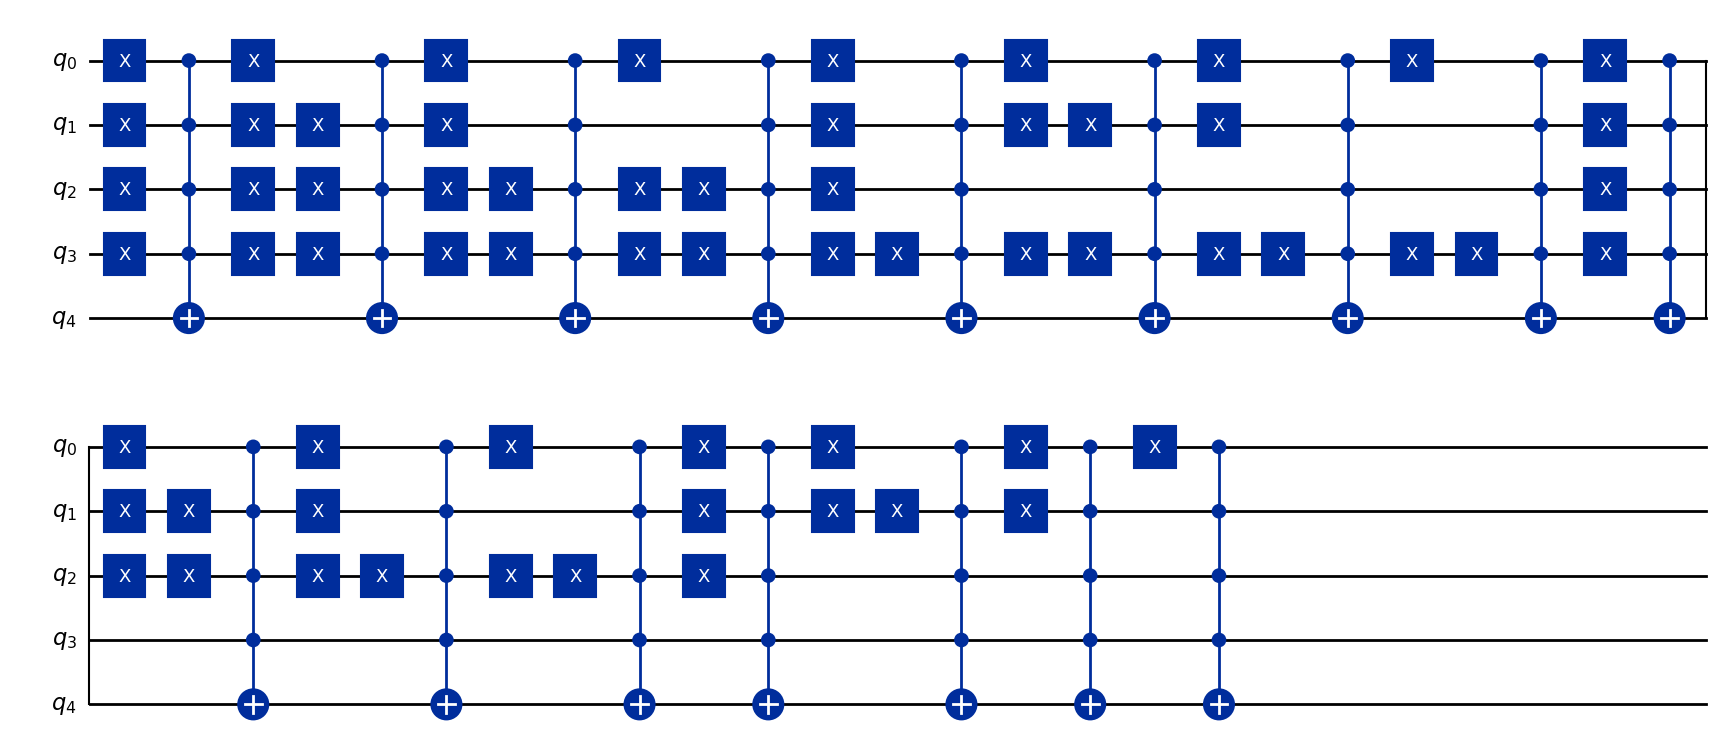

In [25]:
# Build oracles
oracles = [build_deutsch_jozsa_oracle(f) for f in functions]

oracles[0].draw('mpl')

### Circuit Example

Below is an example of a fully composed circuit implementing the Deutsch-Jozsa algorithm, with the oracle composed as a blackbox. The beginning of the circuit sees each qubit transformed by a Hadamard gate, as seen in Problem 4. This transformation can be represented as $H^{\otimes n}$.

The oracle is subsequently introduced to query the function, followed by the final set of Hadamard gates to measure the states of all input qubits. 

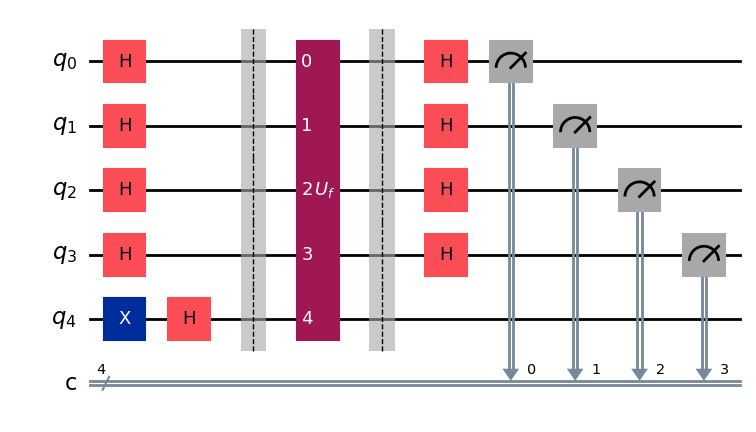

In [26]:
# Compose and display the full Deutsch-Jozsa circuit
dj_start = qiskit.QuantumCircuit(n + 1, n)
dj_start.x(n)
dj_start.h(range(n + 1))

# Choose a random oracle and apply a blackbox label
blackbox = oracles[random.randint(0, 3)].to_gate()
blackbox.label = "$U_f$"

dj_end = qiskit.QuantumCircuit(n + 1, n)
dj_end.h(range(n))

dj = qiskit.QuantumCircuit(n + 1, n)  # n+1 qubits, n classical bits
dj.compose(dj_start, inplace=True)
dj.barrier()
dj.compose(blackbox, inplace=True)
dj.barrier()
dj.compose(dj_end, inplace=True)

# Measure the qubits
dj.measure(range(n), range(n))

dj.draw('mpl')

### Running the Deutsch-Jozsa Circuit

This function then runs and simulates a fully composed Deutsch-Jozsa circuit using the classical functions previously acquired from Problem 1. If *all* results are $0$, the function is constant. If *any* result is $1$, it is balanced.

In [27]:
def run_dj_algorithm(f):
	"""
	Constructs and runs the Deutsch-Jozsa algorithm on a simulator for a given function f, and 
	determines whether f is constant or balanced.

	Parameters:
		f (function): The function to be tested, which takes n binary inputs and returns 0 or 1.

	Returns:
		str: A string indicating whether the function is constant or balanced, along with the measurement result.
	"""	

	# Construct beginning of circuit
	start = qiskit.QuantumCircuit(n + 1)
	start.x(n)
	start.h(range(n + 1))

	# Acquire the oracle for the given function
	oracle = build_deutsch_jozsa_oracle(f, n_inputs=n)

	# Construct end of circuit
	end = qiskit.QuantumCircuit(n + 1)
	end.h(range(n))

	# Compose the full circuit
	dj_circuit = qiskit.QuantumCircuit(n + 1, n)
	dj_circuit.compose(start, inplace=True)
	dj_circuit.barrier()
	dj_circuit.compose(oracle, inplace=True)
	dj_circuit.barrier()
	dj_circuit.compose(end, inplace=True)

	# Measure the input qubits
	dj_circuit.measure(range(n), range(n))

	# Run the circuit on the AER simulator
	simulator = aer.AerSimulator()
	compiled_circuit = qiskit.transpile(dj_circuit, simulator)
	result = simulator.run(compiled_circuit, shots=1, memory=True).result()
	measurement = result.get_memory()[0]

	# Determine if the function is constant or balanced
	# 
	# If there is at least one '1' in the measurement, the function is balanced.
	# Otherwise if all bits are '0', the function is constant.
	if "1" in measurement:
		return f"Balanced - {measurement}"
	return f"Constant - {measurement}"

### Test

The algorithm is run for each of the functions previously defined, where it will assert that two of the functions are constant and the other two balanced.

In [28]:
# Test all of the functions
[run_dj_algorithm(f) for f in functions]

['Constant - 0000', 'Balanced - 1110', 'Balanced - 0110', 'Constant - 0000']

We can verify the accuracy of this quantum algorithm by comparing the results with ones acquired from the classical method `determine_constant_balanced` defined in [Problem 2](#problem-2-classical-testing-for-function-type).

In [29]:
[determine_constant_balanced(f, verbose=False) for f in functions]

['Constant', 'Balanced', 'Balanced', 'Constant']

## Conclusion
<hr>

Following the completion of all of the problems in this notebook, an argument in favour of quantum algorithms is apparent. In a summary:

- **Problem 1** introduced a function to generate all possible binary strings of length $n$, which were then used to generate the necessary boolean functions to carry out the later exercises.
- **Problem 2** showed a classical implementation to determine a global property of a function after a number of queries. 
- **Problem 3** featured the creation of the necessary quantum oracles to implement the boolean functions of Deutsch's algorithm.
- **Problem 4** saw the composition of Deutsch's algorithm using the oracles created in Problem 3 using a quantum circuit created with Qiskit.
- **Problem 5** leverages everything learned thus far and composes a quantum circuit to implement the Deutsch-Jozsa algorithm.

The implementation of Deustch's algorithm, and more especially Deutsch-Jozsa, highlights the stark contrast between classical and quantum computing algorithms. A problem that required at most $2^{n-1} + 1$ queries to resolve by classical means, only required a single query to solve using quantum methods. While this may not appear to be a substantial difference, this gap grows exponentially relative to the size of $n$, and its application could prove to be incredibly beneficial to certain technologies. 